# 🚀 1. Import Libraries

In [1]:
# Basic
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time Series
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ML Models
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

# 📂 2. Load Dataset

In [2]:
df = pd.read_csv("mumbai-monthly-rains.csv")

In [3]:
df.head()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,Oct,Nov,Dec,Total
0,1901,13.116602,0.000000,0.000000,3.949669,17.139791,640.714036,888.369692,545.045796,64.271513,9.871696,0.000000,0.000000,2182.478796
1,1902,0.000000,0.000000,0.000000,0.000000,0.355001,247.998782,408.433730,566.595863,688.913455,28.654092,0.488864,19.526547,1960.966334
2,1903,0.000000,0.000000,0.844034,0.000000,220.568740,370.849048,902.447896,602.420828,264.589816,157.892877,0.000000,0.000000,2519.613240
3,1904,0.000000,0.000000,11.381769,0.000000,0.000000,723.081969,390.886799,191.581927,85.704754,38.679948,0.000000,0.000000,1441.317168
4,1905,0.662561,1.713452,0.000000,0.000000,0.000000,123.870892,581.827975,167.382149,172.297723,7.365924,24.903575,0.000000,1080.024250


# 🔄 3. Reshape Data (IMPORTANT STEP)

In [4]:
df = df.drop(columns=['Total'])

df_melt = df.melt(id_vars=['Year'], var_name='Month', value_name='Rainfall')

month_map = {
    'Jan':1, 'Feb':2, 'Mar':3, 'April':4,
    'May':5, 'June':6, 'July':7,
    'Aug':8, 'Sept':9,
    'Oct':10, 'Nov':11, 'Dec':12
}

df_melt['Month'] = df_melt['Month'].map(month_map)

df_melt['Date'] = pd.to_datetime(
    df_melt['Year'].astype(str) + '-' + df_melt['Month'].astype(str)
)

df_melt = df_melt.sort_values('Date')
df_melt.set_index('Date', inplace=True)

df_melt = df_melt[['Rainfall']]
df_melt.head()

,Rainfall
Date,
1901-01-01,13.116602
1901-02-01,0.000000
1901-03-01,0.000000
1901-04-01,3.949669
1901-05-01,17.139791


# 📊 4. EDA (Visualization)

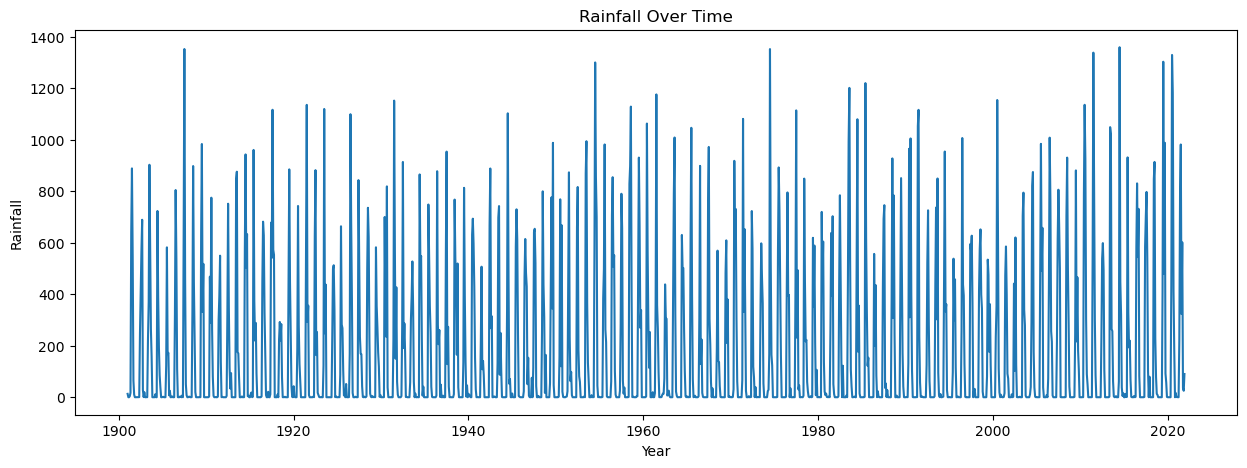

In [5]:
plt.figure(figsize=(15,5))
plt.plot(df_melt)
plt.title("Rainfall Over Time")
plt.xlabel("Year")
plt.ylabel("Rainfall")
plt.show()

### Monthly Seasonality

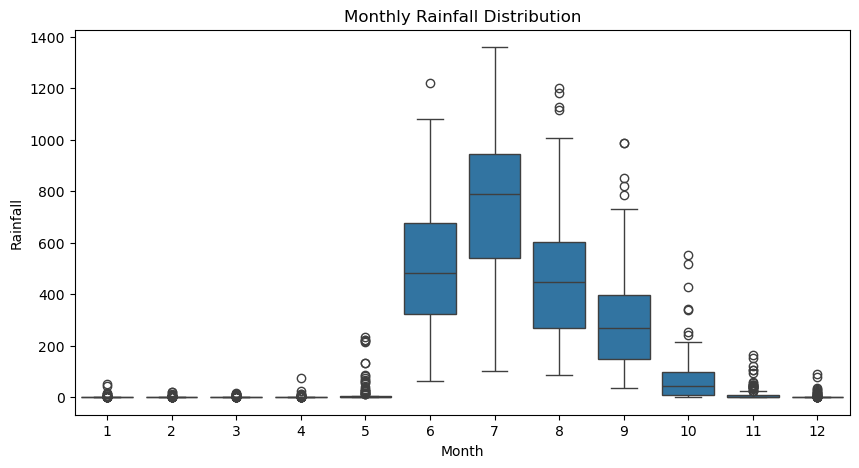

In [6]:
df_melt['Month'] = df_melt.index.month

plt.figure(figsize=(10,5))
sns.boxplot(x='Month', y='Rainfall', data=df_melt)
plt.title("Monthly Rainfall Distribution")
plt.show()

# 📉 5. Stationarity Check (ADF Test)

In [7]:
def adf_test(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

adf_test(df_melt['Rainfall'])

ADF Statistic: -5.59217515746587
p-value: 1.3214840668522509e-06


👉 If p-value > 0.05 → not stationary

In [8]:
def test_stationarity(timeseries):
    # Dickey-Fuller test
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value

    return dfoutput

result = test_stationarity(df_melt['Rainfall'])
print('Augmented Dickry-Fuller Test:')
print(result)

Augmented Dickry-Fuller Test:
Test Statistic                   -5.592175
p-value                           0.000001
#Lags Used                       23.000000
Number of Observations Used    1428.000000
Critical Value (1%)              -3.434938
Critical Value (5%)              -2.863566
Critical Value (10%)             -2.567849
dtype: float64


In [9]:
df_melt['Rainfall_diff'] = df_melt['Rainfall'].diff()
df_melt.dropna(inplace=True)

adf_test(df_melt['Rainfall_diff'])

ADF Statistic: -17.70153272818667
p-value: 3.5351079586036406e-30


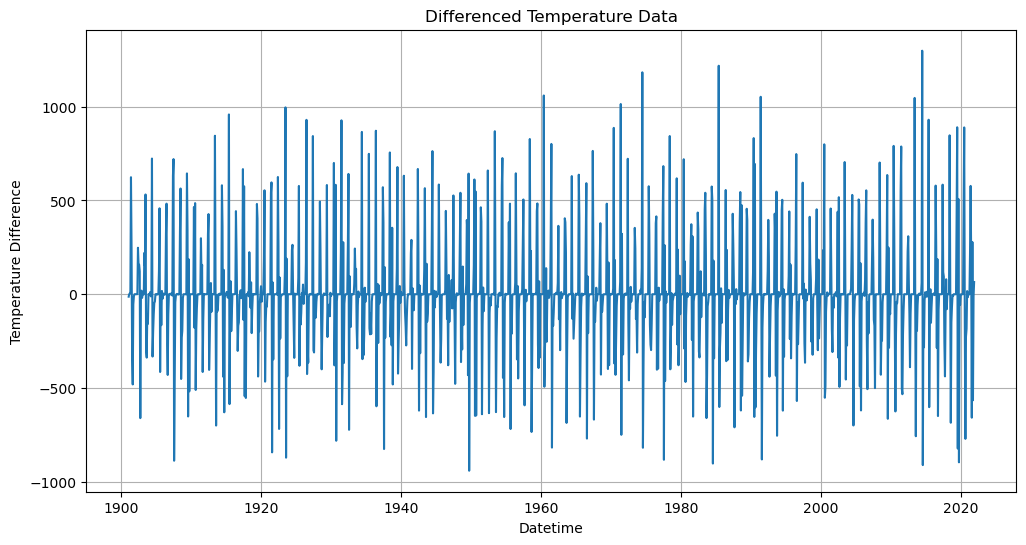

In [10]:
plt.figure(figsize=(12,6))
plt.plot(df_melt['Rainfall_diff'])
plt.title('Differenced Temperature Data')
plt.xlabel('Datetime')
plt.ylabel('Temperature Difference')
plt.grid(True)
plt.show()

In [11]:
result = test_stationarity(df_melt['Rainfall_diff'])
print("Augmented Dicky-Fuller Test on Differenced Data:")
print(result)

Augmented Dicky-Fuller Test on Differenced Data:
Test Statistic                -1.770153e+01
p-value                        3.535108e-30
#Lags Used                     2.200000e+01
Number of Observations Used    1.428000e+03
Critical Value (1%)           -3.434938e+00
Critical Value (5%)           -2.863566e+00
Critical Value (10%)          -2.567849e+00
dtype: float64


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_acf_pacf(data, title='ACF and PACF Plots', lags=15, seasonal_period=None):
    """
    Generates ACF and PACF plots for a given time series data.

    Args:
        data (pd.Series or np.array): The time series data (should be stationary for interpretation).
        title (str): The main title for the plot figure.
        lags (int): Number of lags to display.
        seasonal_period (int): The seasonal period (e.g., 12 for monthly, 7 for weekly).
    """
    plt.figure(figsize=(10,6))
    plt.suptitle(title, fontsize=16)

    # Plot ACF
    plot_acf(data, lags=lags, zero=False)
    plt.xticks(np.arange(0,lags+1))
    plt.grid(True)
    # plt.set_title('Autocorrelation Function (ACF)')
    # plt.set_xlabel('Lags')
    # plt.set_ylabel('Correlation')
    # plt.grid(True)
    

    # Plot PACF
    plot_pacf(data, lags=lags, zero=False, method='ols')
    # plt.set_title('Partial Autocorrelation Function (PACF)')
    # plt.set_xlabel('Lags')
    # plt.set_ylabel('Correlation')
    # plt.grid(True)

    # Highlight seasonal lags if period is provided
    if seasonal_period:
        for i in range(1, lags // seasonal_period + 1):
            plt.axvline(x=i * seasonal_period, color='r', linestyle='--', alpha=0.5)
            plt.axvline(x=i * seasonal_period, color='r', linestyle='--', alpha=0.5)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.xticks(np.arange(0,lags+1))
    plt.grid(True)
    plt.show()

# Example Usage (replace with your data)
# Assume 'your_time_series_data' is a pandas Series after any necessary differencing
# from your_data_source import your_time_series_data 

# Placeholder for demonstration data (uncomment and use with real data)
# data = pd.Series([...]) 
# plot_acf_pacf(data, lags=40, seasonal_period=12) # For monthly data (period=12)


<Figure size 1000x600 with 0 Axes>

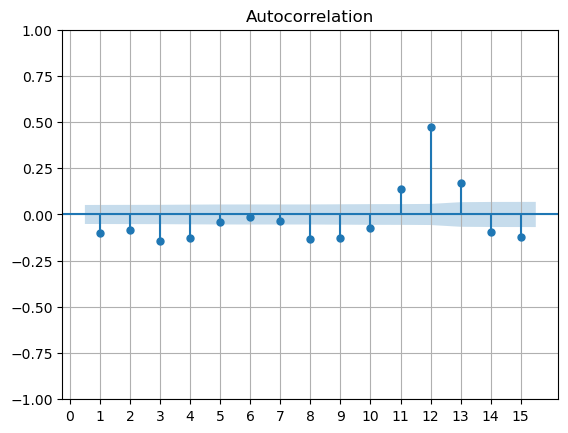

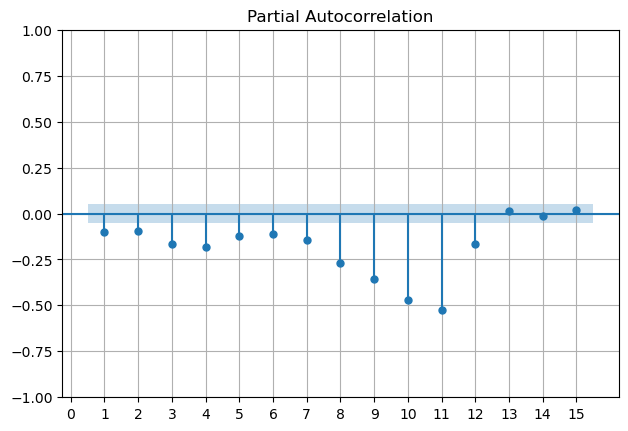

In [13]:
plot_acf_pacf(df_melt['Rainfall_diff'])

# ✂️ 7. Train-Test Split (Time-Based)

In [14]:
train = df_melt[:'2010']
test = df_melt['2011':]

# 🤖 8. SARIMA Model (MAIN MODEL)

In [15]:
model = SARIMAX(train['Rainfall'],
                order=(1,1,1),
                seasonal_order=(1,1,1,12))

sarima_model = model.fit()
print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                           Rainfall   No. Observations:                 1319
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -8367.503
Date:                            Sun, 26 Apr 2026   AIC                          16745.006
Time:                                    16:31:54   BIC                          16770.880
Sample:                                02-01-1901   HQIC                         16754.712
                                     - 12-01-2010                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1      -9.121e-05      0.019     -0.005      0.996      -0.037       0.037
ma.L1         -0.9999      0.288   

# 📈 9. Predictions (SARIMA)

In [16]:
sarima_pred = sarima_model.predict(start=test.index[0], end=test.index[-1])

# Evaluation
mae = mean_absolute_error(test['Rainfall'], sarima_pred)
rmse = np.sqrt(mean_squared_error(test['Rainfall'], sarima_pred))

print("SARIMA MAE:", mae)
print("SARIMA RMSE:", rmse)

SARIMA MAE: 100.87646695841195
SARIMA RMSE: 186.265470538816


# 📊 10. Plot Predictions

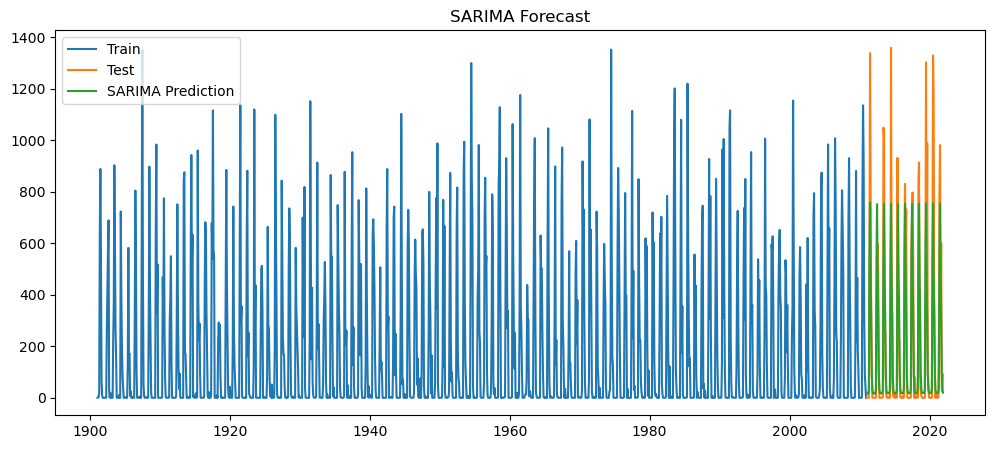

In [17]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train['Rainfall'], label='Train')
plt.plot(test.index, test['Rainfall'], label='Test')
plt.plot(test.index, sarima_pred, label='SARIMA Prediction')
plt.legend()
plt.title("SARIMA Forecast")
plt.show()

# 🤖 11. Machine Learning Approach (Random Forest)

## Create Lag Features

In [18]:
df_ml = df_melt.copy()

for i in range(1,13):
    df_ml[f'lag_{i}'] = df_ml['Rainfall'].shift(i)

df_ml.dropna(inplace=True)

## Train-Test Split

In [19]:
train_ml = df_ml[:'2010']
test_ml = df_ml['2011':]

X_train = train_ml.drop('Rainfall', axis=1)
y_train = train_ml['Rainfall']

X_test = test_ml.drop('Rainfall', axis=1)
y_test = test_ml['Rainfall']

## Train Model

In [20]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Predictions

In [21]:
rf_pred = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 29.35831090941122
Random Forest RMSE: 76.05221847604761


# 📊 12. Compare Models

In [22]:
print("SARIMA RMSE:", rmse)
print("Random Forest RMSE:", rmse_rf)

SARIMA RMSE: 186.265470538816
Random Forest RMSE: 76.05221847604761


# 🔮 13. Future Forecast (Next 12 Months)

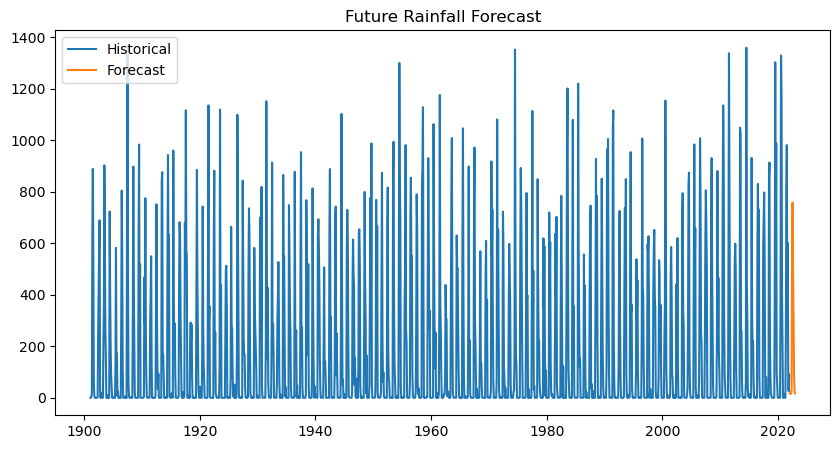

In [23]:
forecast = sarima_model.forecast(steps=12)

plt.figure(figsize=(10,5))
plt.plot(df_melt.index, df_melt['Rainfall'], label='Historical')
plt.plot(pd.date_range(df_melt.index[-1], periods=12, freq='M'), forecast, label='Forecast')
plt.legend()
plt.title("Future Rainfall Forecast")
plt.show()

# 📌 14. Save Model (Optional)

In [24]:
import pickle

with open("sarima_model.pkl", "wb") as f:
    pickle.dump(sarima_model, f)

# 📄 15. Key Insights (Write in Notebook Markdown)

Add this section manually:

* Rainfall shows strong seasonality (June–Sept peak)
* SARIMA performs well due to seasonal modeling
* Random Forest captures patterns but less effective for time dependency
* Forecast helps in water resource planning

# 🚀 16. XGBoost Model (Better than Random Forest)

## 📦 Install

In [25]:
!pip install xgboost

## 📥 Import

In [26]:
from xgboost import XGBRegressor

## ⚙️ Train XGBoost

In [27]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## 🔮 Predictions

In [28]:
xgb_pred = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 24.528540200510008
XGBoost RMSE: 58.22116423121062


## 📊 Compare All Models

In [29]:
print("SARIMA RMSE:", rmse)
print("Random Forest RMSE:", rmse_rf)
print("XGBoost RMSE:", rmse_xgb)

SARIMA RMSE: 186.265470538816
Random Forest RMSE: 76.05221847604761
XGBoost RMSE: 58.22116423121062


## 📈 Plot XGBoost Predictions

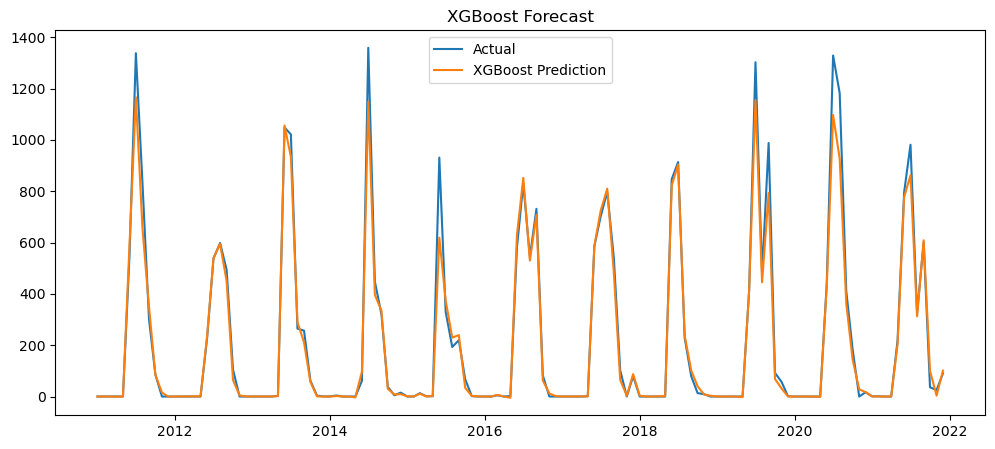

In [30]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, xgb_pred, label='XGBoost Prediction')
plt.legend()
plt.title("XGBoost Forecast")
plt.show()

# 🌟 17. Prophet Model (VERY IMPRESSIVE FOR RECRUITERS)

## 📦 Install Prophet

In [31]:
!pip install prophet

## 📥 Import

In [32]:
from prophet import Prophet

## 🔄 Prepare Data for Prophet

Prophet requires:

* `ds` → date
* `y` → value

In [33]:
df_prophet = df_melt.reset_index()
df_prophet = df_prophet[['Date', 'Rainfall']]
df_prophet.columns = ['ds', 'y']

## ✂️ Train-Test Split

In [34]:
train_prophet = df_prophet[df_prophet['ds'] <= '2010-12-31']
test_prophet = df_prophet[df_prophet['ds'] > '2010-12-31']

## 🤖 Train Prophet Model

In [35]:
model_prophet = Prophet(
    yearly_seasonality=True,
    seasonality_mode='additive'
)

model_prophet.fit(train_prophet)

16:32:14 - cmdstanpy - INFO - Chain [1] start processing
16:32:15 - cmdstanpy - INFO - Chain [1] done processing


## 🔮 Future Forecast

In [36]:
future = model_prophet.make_future_dataframe(periods=len(test_prophet), freq='M')

forecast = model_prophet.predict(future)

## 📊 Extract Predictions for Test Set

In [37]:
# Ensure datetime
forecast['ds'] = pd.to_datetime(forecast['ds'])
test_prophet['ds'] = pd.to_datetime(test_prophet['ds'])

# Normalize to month start
forecast['ds'] = forecast['ds'].dt.to_period('M').dt.to_timestamp()
test_prophet['ds'] = test_prophet['ds'].dt.to_period('M').dt.to_timestamp()

# Merge safely
merged = pd.merge(test_prophet, forecast[['ds', 'yhat']], on='ds', how='inner')

y_pred_prophet = merged['yhat'].values
y_true_prophet = merged['y'].values

## 📏 Evaluation

In [38]:
mae_prophet = mean_absolute_error(y_true_prophet, y_pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(y_true_prophet, y_pred_prophet))

print("Prophet MAE:", mae_prophet)
print("Prophet RMSE:", rmse_prophet)

Prophet MAE: 171.15966321795887
Prophet RMSE: 284.6878800294327


## 📈 Prophet Forecast Plot

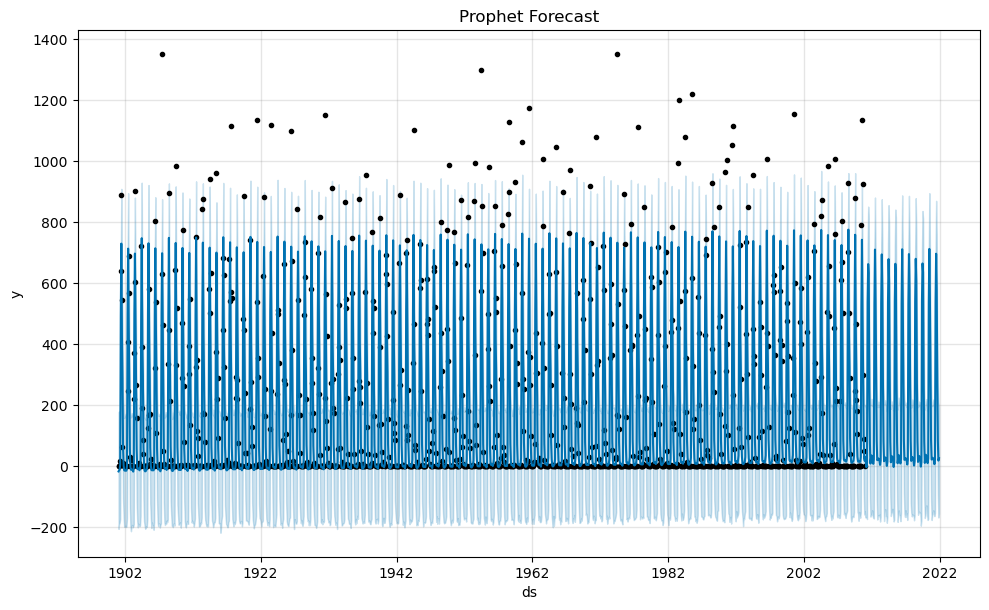

In [39]:
model_prophet.plot(forecast)
plt.title("Prophet Forecast")
plt.show()

## 📊 Components

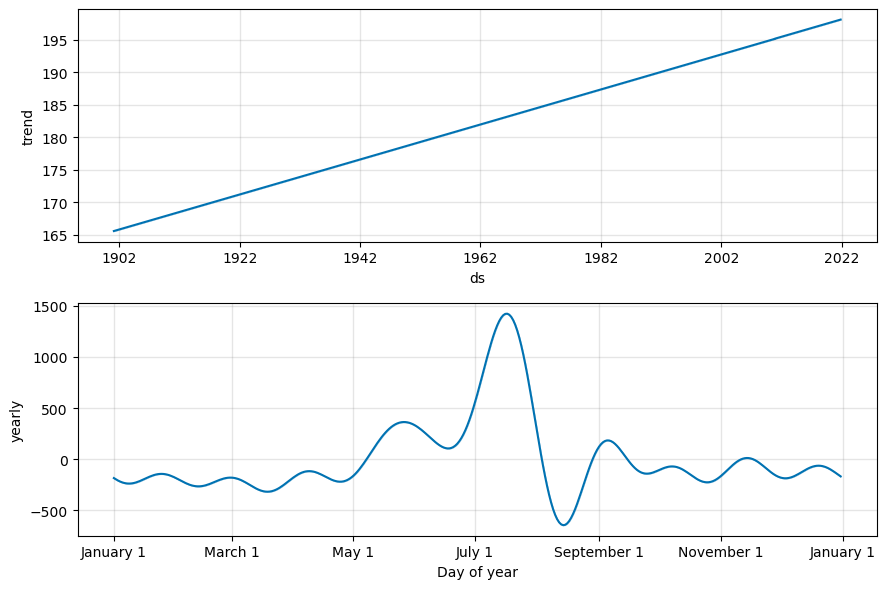

In [40]:
model_prophet.plot_components(forecast)
plt.show()

## 🏆 Final Model Comparison Table

In [41]:
results = pd.DataFrame({
    'Model': ['SARIMA', 'Random Forest', 'XGBoost', 'Prophet'],
    'RMSE': [rmse, rmse_rf, rmse_xgb, rmse_prophet]
})

print(results.sort_values(by='RMSE'))

           Model        RMSE
2        XGBoost   58.221164
1  Random Forest   76.052218
0         SARIMA  186.265471
3        Prophet  284.687880


# 🚀 18. LSTM Model (Deep Learning Approach)

## 📦 Install

In [42]:
!pip install tensorflow

## 📥 Imports

In [43]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

## ⚙️ Prepare Data for LSTM

👉 LSTM needs:

* Scaled data
* Sequential input (timesteps)

### 🔄 Use Only Rainfall Column

In [44]:
data = df_melt[['Rainfall']].copy()

### 📉 Scaling

In [45]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

### 🧠 Create Sequences

👉 We use last 12 months → predict next month

In [46]:
def create_sequences(data, time_steps=12):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, 12)

## ✂️ Train-Test Split

In [47]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## 🤖 Build LSTM Model

In [48]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(12,1)))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

## 🏋️ Train Model

In [49]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.0378 - val_loss: 0.0346
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0224 - val_loss: 0.0284
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0193 - val_loss: 0.0218
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0191 - val_loss: 0.0225
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0178 - val_loss: 0.0259
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0186 - val_loss: 0.0204
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0194 - val_loss: 0.0206
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0171 - val_loss: 0.0207
Epoch 9/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0170 - val_loss: 0.0226
Epoch 10/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0178 - val_loss: 0.0210
Epoch 11/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0170 - val_loss: 0.0206
Epoch 12/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0

## 🔮 Predictions

In [50]:
y_pred = model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step  


## 🔁 Inverse Scaling

In [51]:
y_pred = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test)

## 📏 Evaluation

In [52]:
mae_lstm = mean_absolute_error(y_test_actual, y_pred)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred))

print("LSTM MAE:", mae_lstm)
print("LSTM RMSE:", rmse_lstm)

LSTM MAE: 112.60839086023469
LSTM RMSE: 204.43270693621838


## 📊 Plot Results

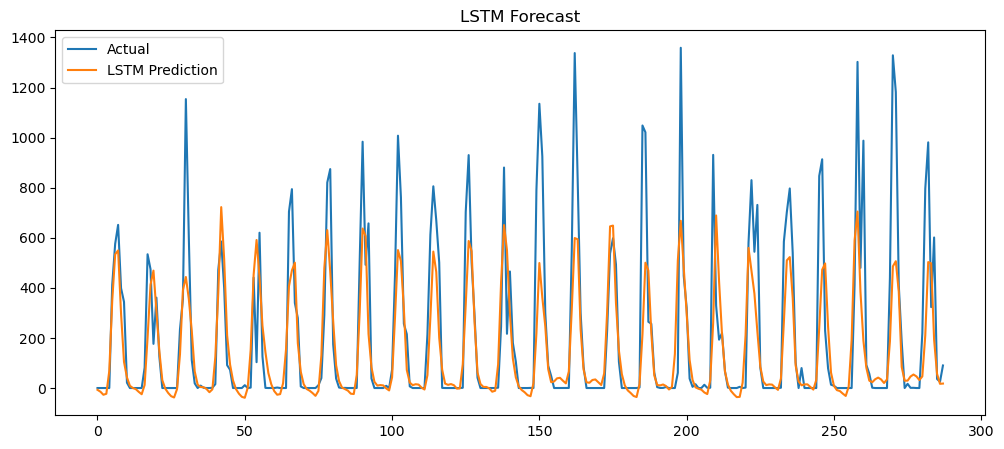

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label='Actual')
plt.plot(y_pred, label='LSTM Prediction')
plt.legend()
plt.title("LSTM Forecast")
plt.show()

## 🔮 Future Prediction (Next 12 Months)

In [54]:
last_sequence = scaled_data[-12:]
future_preds = []

current_seq = last_sequence.copy()

for _ in range(12):
    pred = model.predict(current_seq.reshape(1,12,1))
    future_preds.append(pred[0][0])
    
    current_seq = np.append(current_seq[1:], pred, axis=0)

future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 619ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


## 📈 Plot Future Forecast

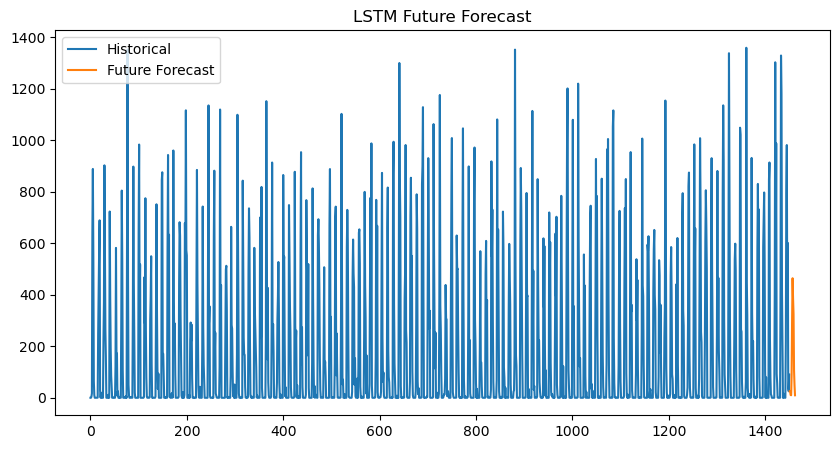

In [55]:
plt.figure(figsize=(10,5))
plt.plot(data.values, label='Historical')
plt.plot(range(len(data), len(data)+12), future_preds, label='Future Forecast')
plt.legend()
plt.title("LSTM Future Forecast")
plt.show()

## 🏆 Add to Model Comparison

In [56]:
print("LSTM RMSE:", rmse_lstm)

LSTM RMSE: 204.43270693621838


# 💾 19. Save XGBoost Model, Feature Importance & 12-Month Forecast

## 💾 Save Trained XGBoost Model

In [57]:
import pickle

with open("xgboost_rainfall_model.pkl", "wb") as f:
    pickle.dump(xgb, f)

print("XGBoost model saved to xgboost_rainfall_model.pkl")

XGBoost model saved to xgboost_rainfall_model.pkl


## 🔬 Feature Importance → CSV

In [58]:
feature_names = list(xgb.feature_names_in_)
importances = xgb.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

feature_importance_df.to_csv("feature_importance.csv", index=False)
print("Feature importance saved to feature_importance.csv")
feature_importance_df

Feature importance saved to feature_importance.csv


,Feature,Importance
0,lag_12,0.480126
1,Rainfall_diff,0.212832
2,Month,0.104161
3,lag_1,0.087669
4,lag_11,0.055542
5,lag_4,0.011032
6,lag_3,0.010315
7,lag_10,0.007891
8,lag_9,0.007811
9,lag_2,0.007234


## 🔮 Forecast Next 12 Months with XGBoost

In [59]:
# Iterative 12-month forecast using the trained XGBoost model
# Features used during training: Month, Rainfall_diff, lag_1 ... lag_12

feature_names = list(xgb.feature_names_in_)

# Start from the last 12 actual rainfall values (most recent first lag = most recent month)
recent_rainfall = df_melt['Rainfall'].tail(12).values.tolist()
last_date = df_melt.index[-1]

future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=12,
    freq='MS'
)

future_predictions = []

for future_date in future_dates:
    row = {}
    # lag_1 = most recent rainfall, lag_2 = the one before it, etc.
    for i in range(1, 13):
        row[f'lag_{i}'] = recent_rainfall[-i]
    row['Month'] = future_date.month
    # Rainfall_diff approximation: difference between the two most recent values
    row['Rainfall_diff'] = recent_rainfall[-1] - recent_rainfall[-2]

    X_future = pd.DataFrame([row])[feature_names]
    pred = float(xgb.predict(X_future)[0])
    pred = max(pred, 0.0)  # rainfall cannot be negative

    future_predictions.append(pred)
    recent_rainfall.append(pred)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Rainfall': future_predictions
})

forecast_df.to_csv("rainfall_forecast_next_12_months.csv", index=False)
print("12-month forecast saved to rainfall_forecast_next_12_months.csv")
forecast_df

12-month forecast saved to rainfall_forecast_next_12_months.csv


,Date,Predicted_Rainfall
0,2022-01-01,146.591675
1,2022-02-01,132.887253
2,2022-03-01,55.512768
3,2022-04-01,0.000000
4,2022-05-01,15.890163
5,2022-06-01,115.629829
6,2022-07-01,305.047272
7,2022-08-01,511.558899
8,2022-09-01,740.244446
9,2022-10-01,757.769958


## 📈 Forecast Plot (Historical + Next 12 Months)

Forecast plot saved to forecast_plot.png


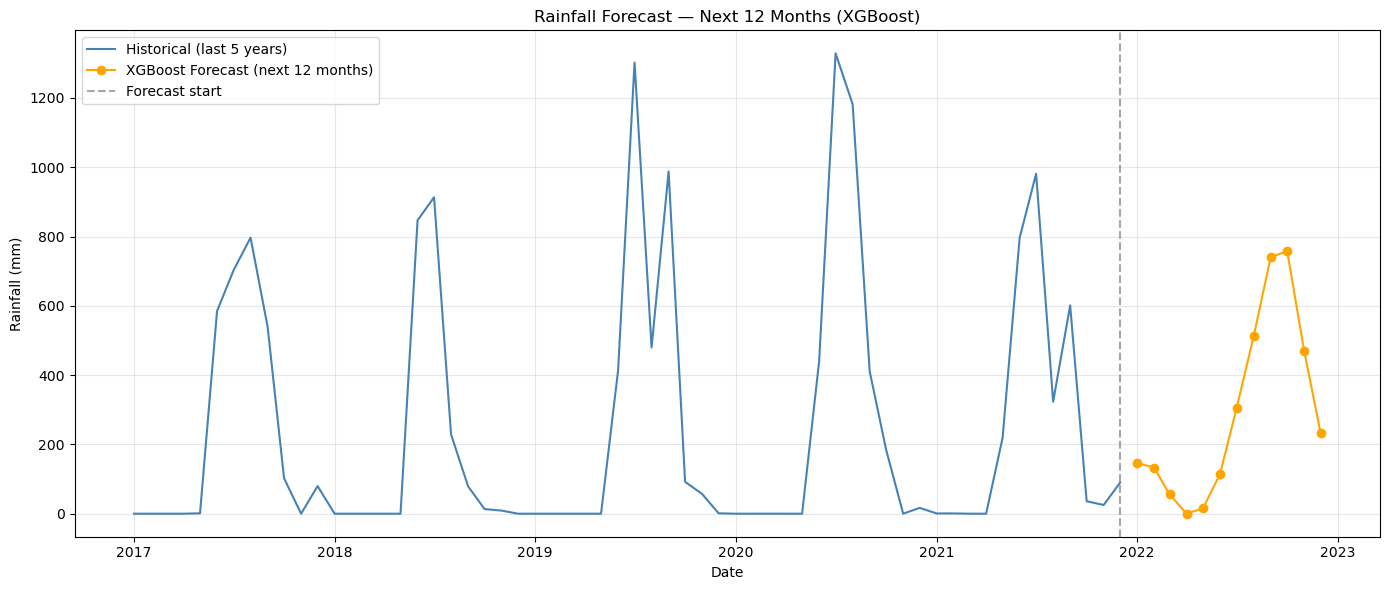

In [60]:
plt.figure(figsize=(14, 6))

# Show last 5 years of history for context
history_tail = df_melt['Rainfall'].tail(60)
plt.plot(history_tail.index, history_tail.values, label='Historical (last 5 years)', color='steelblue')

plt.plot(forecast_df['Date'], forecast_df['Predicted_Rainfall'],
         label='XGBoost Forecast (next 12 months)', color='orange', marker='o')

plt.axvline(x=df_melt.index[-1], color='gray', linestyle='--', alpha=0.7, label='Forecast start')
plt.title("Rainfall Forecast — Next 12 Months (XGBoost)")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("forecast_plot.png", dpi=150, bbox_inches='tight')
print("Forecast plot saved to forecast_plot.png")
plt.show()